# Chương 4 – RNN
Nguyễn Minh Vinh · B23DCCN934. Code tự triển khai và kết quả thật. Chạy tuần tự từng cell; các cell train sẽ huấn luyện lại. So sánh scratch / Keras / PyTorch cùng cấu trúc, initialization, split và minibatch.

In [1]:
import os,sys,json
from pathlib import Path
os.environ['OPENBLAS_NUM_THREADS']='2'
os.environ['OMP_NUM_THREADS']='2'
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/experiment.py').exists())
sys.path.insert(0,str(ROOT/'src'))
from IPython.display import display,Image,Code


## 1. Scratch: forward, loss, backward và SGD
NumPy không dùng autograd. MLP áp dụng chain rule; CNN tính gradient kernel từ patch và phân phối gradient average pooling; RNN thực hiện BPTT từ bước cuối về đầu. Gradient clipping global norm=1 trước SGD.

In [2]:
"""NumPy forward/backward/SGD. No automatic differentiation in this module."""
import numpy as np

def initialize(kind,shape,outputs,seed=42):
    rng=np.random.default_rng(seed)
    def w(s,scale):return (rng.normal(size=s)*scale).astype(np.float32)
    if kind=='mlp':return {'w':w((shape[0],32),np.sqrt(2/shape[0])),'b':np.zeros(32,np.float32),'v':w((32,outputs),np.sqrt(1/32)),'c':np.zeros(outputs,np.float32)}
    if kind=='cnn':
        height,width,channels=shape;flat=((height-2)//2)*((width-2)//2)*8
        return {'w':w((3,3,channels,8),np.sqrt(2/(9*channels))),'b':np.zeros(8,np.float32),'v':w((flat,outputs),np.sqrt(1/flat)),'c':np.zeros(outputs,np.float32)}
    return {'w':w((shape[-1],16),np.sqrt(1/shape[-1])),'u':w((16,16),.15),'b':np.zeros(16,np.float32),'v':w((16,outputs),.2),'c':np.zeros(outputs,np.float32)}

def patches(x):
    return np.lib.stride_tricks.sliding_window_view(x,(3,3),axis=(1,2)).transpose(0,1,2,4,5,3)

def forward(p,x,kind,cache=False):
    if kind=='mlp':
        z=x@p['w']+p['b'];h=np.maximum(z,0);aux=(x,z,h)
    elif kind=='cnn':
        cols=patches(x);z=np.tensordot(cols,p['w'],axes=([3,4,5],[0,1,2]))+p['b']
        a=np.maximum(z,0);n,hh,ww,ch=a.shape
        h=a.reshape(n,hh//2,2,ww//2,2,ch).mean((2,4)).reshape(n,-1);aux=(cols,z,h)
    else:
        h=np.zeros((len(x),16),dtype=x.dtype);states=[h]
        for t in range(x.shape[1]):
            h=np.tanh(x[:,t]@p['w']+h@p['u']+p['b']);states.append(h)
        aux=(x,states,h)
    y=h@p['v']+p['c']
    return (y,aux) if cache else y

def objective(logits,y,task,weight=None):
    n=len(y)
    if task=='regression':
        delta=logits[:,0]-y
        return float(np.mean(delta**2)),(2*delta/n)[:,None]
    a=logits-logits.max(1,keepdims=True);exp=np.exp(a);prob=exp/exp.sum(1,keepdims=True)
    weights=np.ones(n) if weight is None else weight[y.astype(int)]
    loss=-(weights*(a[np.arange(n),y.astype(int)]-np.log(exp.sum(1)))).mean()
    grad=prob.copy();grad[np.arange(n),y.astype(int)]-=1;grad*=weights[:,None]/n
    return float(loss),grad

def backward(p,aux,dy,kind):
    x,z,h=aux;g={'v':h.T@dy,'c':dy.sum(0)};dh=dy@p['v'].T
    if kind=='mlp':
        dz=dh*(z>0);g.update(w=x.T@dz,b=dz.sum(0))
    elif kind=='cnn':
        n,hh,ww,ch=z.shape
        pooled=dh.reshape(n,hh//2,ww//2,ch)
        dz=np.repeat(np.repeat(pooled,2,axis=1),2,axis=2)/4*(z>0)
        g.update(w=np.tensordot(x,dz,axes=([0,1,2],[0,1,2])),b=dz.sum((0,1,2)))
    else:
        states=z;g.update(w=np.zeros_like(p['w']),u=np.zeros_like(p['u']),b=np.zeros_like(p['b']))
        for t in range(x.shape[1]-1,-1,-1):
            dz=dh*(1-states[t+1]**2)
            g['w']+=x[:,t].T@dz;g['u']+=states[t].T@dz;g['b']+=dz.sum(0)
            dh=dz@p['u'].T
    return g

def step(p,g,lr,clip=1.):
    norm=np.sqrt(sum(np.sum(v.astype(np.float64)**2) for v in g.values()))
    scale=min(1.,clip/(norm+1e-12))
    for k in p:p[k]-=lr*scale*g[k]

def probabilities(z):
    a=np.exp(z-z.max(1,keepdims=True));return a/a.sum(1,keepdims=True)


## 2. Hai framework cùng cấu trúc
PyTorch dùng ParameterDict và phép toán tensor tự động đạo hàm, đặc biệt RNN chỉ có một bias để trùng với scratch và Keras. Keras dùng Dense/Conv2D/SimpleRNN. Head giữ thứ tự flatten NHWC cho cả ba.

In [3]:
"""Matched architectures with one canonical recurrent bias in every implementation."""
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL','2')
os.environ.setdefault('OMP_NUM_THREADS','2')
os.environ.setdefault('OPENBLAS_NUM_THREADS','2')
os.environ.setdefault('TF_NUM_INTRAOP_THREADS','2')
os.environ.setdefault('TF_NUM_INTEROP_THREADS','1')
import torch
from torch import nn
import tensorflow as tf
import numpy as np
torch.set_num_threads(2)

class TorchModel(nn.Module):
    def __init__(self,p,kind):
        super().__init__();self.kind=kind
        self.params=nn.ParameterDict({k:nn.Parameter(torch.tensor(v.copy())) for k,v in p.items()})
    def forward(self,x):
        p=self.params
        if self.kind=='mlp':h=torch.relu(x@p['w']+p['b'])
        elif self.kind=='cnn':
            a=nn.functional.conv2d(x.permute(0,3,1,2),p['w'].permute(3,2,0,1),p['b'])
            h=nn.functional.avg_pool2d(torch.relu(a),2).permute(0,2,3,1).reshape(len(x),-1)
        else:
            h=torch.zeros((len(x),16),dtype=x.dtype,device=x.device)
            for t in range(x.shape[1]):h=torch.tanh(x[:,t]@p['w']+h@p['u']+p['b'])
        return h@p['v']+p['c']

def keras_model(p,kind,shape):
    layers=tf.keras.layers
    inputs=layers.Input(shape=shape)
    if kind=='mlp':h=layers.Dense(32,activation='relu',name='hidden')(inputs)
    elif kind=='cnn':h=layers.Flatten()(layers.AveragePooling2D(2)(layers.Conv2D(8,3,activation='relu',name='hidden')(inputs)))
    else:h=layers.SimpleRNN(16,activation='tanh',name='hidden')(inputs)
    model=tf.keras.Model(inputs,layers.Dense(p['c'].size,name='head')(h))
    model.get_layer('hidden').set_weights([p['w'],p['u'],p['b']] if kind=='rnn' else [p['w'],p['b']])
    model.get_layer('head').set_weights([p['v'],p['c']]);return model

def export(model,framework,kind):
    if framework=='pytorch':return {k:v.detach().numpy().copy() for k,v in model.params.items()}
    values=model.get_layer('hidden').get_weights();p=dict(zip(['w','u','b'] if kind=='rnn' else ['w','b'],values));p['v'],p['c']=model.get_layer('head').get_weights();return p


## 3. Vòng train và metric
Cùng seed42, SGD không momentum, lr0,02 (MLP/RNN) hoặc0,04(CNN), batch128; epoch18 hoặc20. Chọn checkpoint validation loss nhỏ nhất. Chọn implementation bằng validation MacroF1 hoặc RMSE, rồi đọc test. Loss có class weights train, nhưng metric tính trên test tự nhiên.

In [4]:
from pathlib import Path
import json,time,copy,sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,average_precision_score,roc_auc_score,mean_squared_error,mean_absolute_error,r2_score,confusion_matrix
from sklearn.linear_model import LogisticRegression,Ridge
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
FRAMEWORKS=['scratch','keras','pytorch']
def load(key):
    z=np.load(ROOT/'data'/f'{key}.npz');d={k:z[k] for k in z.files};d['meta']=json.loads((ROOT/'results'/key/'summary.json').read_text(encoding='utf-8'));d['out']=ROOT/'results'/key;return d
def restore_target(d,indices,z):
    meta=d['meta'];v=z[:,0]*meta['y_std']+meta['y_mean']
    return d['last_close'][indices]*np.exp(v) if meta['key']=='stock' else np.expm1(v)
def metrics(d,ix,z):
    if d['meta']['task']=='regression':
        y=d['actual_close'][ix] if d['meta']['key']=='stock' else d['raw_y'][ix];p=restore_target(d,ix,z)
        return dict(RMSE=float(np.sqrt(mean_squared_error(y,p))),MAE=float(mean_absolute_error(y,p)),R2=float(r2_score(y,p)))
    y=d['y'][ix];prob=probabilities(z);pred=prob.argmax(1)
    m=dict(Accuracy=float(accuracy_score(y,pred)),MacroF1=float(f1_score(y,pred,average='macro',zero_division=0)))
    if prob.shape[1]==2:m.update(F1=float(f1_score(y,pred,zero_division=0)),Precision=float(precision_score(y,pred,zero_division=0)),Recall=float(recall_score(y,pred,zero_division=0)),AP=float(average_precision_score(y,prob[:,1])),ROC_AUC=float(roc_auc_score(y,prob[:,1])))
    return m
def predict(p,x,kind,batch=256):return np.concatenate([forward(p,x[i:i+batch],kind) for i in range(0,len(x),batch)])
def train(key,framework,seed=42):
    d=load(key);meta=d['meta'];kind=meta['kind'];task=meta['task'];x=d['x'];y=d['y'];tr,va=d['train'],d['val']
    outputs=len(meta['classes']) if task=='classification' else 1;p=initialize(kind,x.shape[1:],outputs,seed)
    epochs=20 if kind=='cnn' else 18;lr=.04 if kind=='cnn' else .02;batch=128
    weight=None
    if task=='classification':
        counts=np.bincount(y[tr].astype(int),minlength=outputs);weight=(len(tr)/(outputs*counts)).astype(np.float32)
    model=None
    if framework=='pytorch':
        model=TorchModel(p,kind);optimizer=torch.optim.SGD(model.parameters(),lr=lr)
        def update(xb,yb):
            optimizer.zero_grad();z=model(torch.tensor(xb))
            loss=((z[:,0]-torch.tensor(yb))**2).mean() if task=='regression' else (torch.nn.functional.cross_entropy(z,torch.tensor(yb,dtype=torch.long),reduction='none')*torch.tensor(weight)[torch.tensor(yb,dtype=torch.long)]).mean()
            loss.backward();torch.nn.utils.clip_grad_norm_(model.parameters(),1.);optimizer.step();return float(loss.detach())
    elif framework=='keras':
        model=keras_model(p,kind,x.shape[1:]);optimizer=tf.keras.optimizers.SGD(learning_rate=lr,global_clipnorm=1.)
        @tf.function(reduce_retracing=True)
        def update(xb,yb):
            with tf.GradientTape() as tape:
                z=model(xb,training=True)
                loss=tf.reduce_mean(tf.square(z[:,0]-yb)) if task=='regression' else tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(labels=tf.cast(yb,tf.int32),logits=z)*tf.gather(weight,tf.cast(yb,tf.int32)))
            optimizer.apply_gradients(zip(tape.gradient(loss,model.trainable_variables),model.trainable_variables));return loss
    else:
        def update(xb,yb):
            z,cache=forward(p,xb,kind,True);loss,dz=objective(z,yb,task,weight);g=backward(p,cache,dz,kind);step(p,g,lr);return loss
    best=np.inf;history=[];start=time.perf_counter()
    for epoch in range(1,epochs+1):
        order=np.random.default_rng(seed+epoch).permutation(tr);total=0
        for i in range(0,len(order),batch):
            ix=order[i:i+batch];total+=float(update(x[ix],y[ix]))*len(ix)
        if model is not None:p=export(model,framework,kind)
        val=objective(predict(p,x[va],kind),y[va],task,weight)[0]
        history.append(dict(epoch=epoch,train_loss=total/len(tr),val_loss=val))
        if val<best:best=val;bestp=copy.deepcopy(p);bestepoch=epoch
        print(key,framework,epoch,round(val,5),flush=True)
    seconds=time.perf_counter()-start;p=bestp;name=f'{framework}_{seed}';out=d['out'];np.savez_compressed(out/f'{name}.npz',**p)
    pd.DataFrame(history).to_csv(out/f'{name}_history.csv',index=False)
    validation=metrics(d,va,predict(p,x[va],kind));test=predict(p,x[d['test']],kind);np.savez_compressed(out/f'{name}_predictions.npz',logits=test,indices=d['test'])
    row=dict(framework=framework,seed=seed,epochs=epochs,best_epoch=bestepoch,lr=lr,batch=batch,parameters=sum(v.size for v in p.values()),seconds=seconds,validation=validation,test=metrics(d,d['test'],test))
    (out/f'{name}.json').write_text(json.dumps(row,indent=2))
    if framework=='pytorch':torch.save(TorchModel(p,kind).state_dict(),out/f'{name}.pth')
    elif framework=='keras':keras_model(p,kind,x.shape[1:]).save(out/f'{name}.keras')
    return row

def summarize(key):
    d=load(key);out=d['out'];meta=d['meta'];rows=[json.loads((out/f'{fw}_42.json').read_text()) for fw in FRAMEWORKS]
    criterion='RMSE' if meta['task']=='regression' else 'MacroF1'
    selected=sorted(rows,key=lambda r:r['validation'][criterion],reverse=meta['task']=='classification')[0]['framework']
    (out/'selection.json').write_text(json.dumps(dict(framework=selected,criterion=criterion,split='validation')))
    table=pd.DataFrame([dict(Framework=r['framework'],**r['test'],Parameters=r['parameters'],TrainSeconds=r['seconds'],BestEpoch=r['best_epoch']) for r in rows]);table.to_csv(out/'comparison.csv',index=False)
    fig,axes=plt.subplots(1,3,figsize=(12,3.2))
    for ax,fw in zip(axes,FRAMEWORKS):
        h=pd.read_csv(out/f'{fw}_42_history.csv');ax.plot(h.epoch,h.train_loss,label='train');ax.plot(h.epoch,h.val_loss,label='val');ax.set_title(fw);ax.legend()
    fig.tight_layout();fig.savefig(out/'learning.png',dpi=150);plt.close(fig)
    te=d['test'];z=np.load(out/f'{selected}_42_predictions.npz')['logits']
    fig,axes=plt.subplots(1,2,figsize=(10,3.5))
    if meta['task']=='classification':
        counts=np.bincount(d['y'].astype(int));axes[0].bar(np.arange(len(counts)),counts);axes[0].set_title('Benchmark label counts')
        cm=confusion_matrix(d['y'][te],z.argmax(1));axes[1].imshow(cm,cmap='Blues');axes[1].set_title(selected+' test confusion')
        for a in range(len(cm)):
            for b in range(len(cm)):axes[1].text(b,a,str(cm[a,b]),ha='center',va='center',fontsize=6)
        baseline_pred=np.full(len(te),np.bincount(d['y'][d['train']].astype(int)).argmax());base=dict(Accuracy=float(accuracy_score(d['y'][te],baseline_pred)),MacroF1=float(f1_score(d['y'][te],baseline_pred,average='macro',zero_division=0)))
        errors=np.flatnonzero(z.argmax(1)!=d['y'][te])[:8];examples=[dict(index=int(te[i]),actual=int(d['y'][te[i]]),prediction=int(z[i].argmax()),score=float(probabilities(z[i:i+1]).max())) for i in errors]
    else:
        actual=d['actual_close'][te] if key=='stock' else d['raw_y'][te];pred=restore_target(d,te,z)
        axes[0].hist(actual,bins=40);axes[0].set_title('Test target distribution')
        axes[1].scatter(actual,pred,s=5,alpha=.4);axes[1].plot([actual.min(),actual.max()],[actual.min(),actual.max()],'k--');axes[1].set(xlabel='Actual',ylabel='Prediction')
        b=d['last_close'][te] if key=='stock' else np.full(len(te),d['raw_y'][d['train']].mean());base=dict(RMSE=float(np.sqrt(mean_squared_error(actual,b))),MAE=float(mean_absolute_error(actual,b)),R2=float(r2_score(actual,b)))
        errors=np.argsort(abs(pred-actual))[-8:][::-1];examples=[dict(index=int(te[i]),actual=float(actual[i]),prediction=float(pred[i]),absolute_error=float(abs(pred[i]-actual[i]))) for i in errors]
    fig.tight_layout();fig.savefig(out/'evaluation.png',dpi=150);plt.close(fig)
    (out/'baseline.json').write_text(json.dumps(base,indent=2));(out/'errors.json').write_text(json.dumps(examples,indent=2))
    # Three observed input/output examples, not predictions invented for the report.
    examples=[]
    for ix in te[:3]:examples.append(dict(index=int(ix),input=np.round(d['x'][ix].reshape(-1)[:8],3).tolist(),target=float(d['raw_y'][ix])))
    (out/'samples.json').write_text(json.dumps(examples,indent=2))
    if meta['kind']=='cnn':
        fig,axes=plt.subplots(2,5,figsize=(10,4))
        for label,ax in enumerate(axes.flat):
            i=te[np.flatnonzero(d['y'][te]==label)[0]];ax.imshow(d['images'][i].squeeze(),cmap='gray' if key=='mnist' else None);ax.set_title(meta['classes'][label],fontsize=8);ax.axis('off')
        fig.tight_layout();fig.savefig(out/'samples.png',dpi=150);plt.close(fig)
    return table


## 4. Dataset stock
AAPL: 30 phiên tám đặc trưng nhân quả → log-return phiên kế tiếp. Chia theo ngày nhãn, chuẩn hóa train-only. Mỗi dự đoán test nhận lịch sử thực đã quan sát, không dự báo đệ quy cả chuỗi. So với persistence Close_t=Close_{t-1}.

In [5]:
import subprocess
if not (ROOT/'data/stock.npz').exists():
    subprocess.run([sys.executable,str(ROOT/'tools/prepare.py'),'stock'],check=True)
data=load('stock')
display(pd.Series(data['meta']))
print('Input shape:',data['x'].shape)
display(pd.DataFrame(data['x'][data['train'][:3]].reshape(3,-1)[:,:8]))
print('Nhãn mẫu:',data['raw_y'][data['train'][:3]])

kind                                                       rnn
task                                                regression
classes                                [No purchase, Purchase]
raw_rows                                                  2766
source       https://github.com/tuananhtrieu1305/ISD_Assign...
protocol     Chronological 70/15/15 by target date; feature...
transform       Causal OHLCV indicators, train standardization
features     [LogReturn, OpenGap, Range, Body, RelativeMA20...
mean         [0.0008318194886669517, 0.0002356943441554904,...
std          [0.01866917684674263, 0.012287449091672897, 0....
y_mean                                                 0.00076
y_std                                                 0.018754
periods      {'train': ['2015-04-28', '2022-10-12'], 'valid...
details      {'dataset': 'AAPL historical stock', 'raw_rows...
key                                                      stock
shape                                                  

Input shape: (2687, 30, 8)


,0,1,2,3,4,5,6,7
0,0.541653,0.171784,-0.289893,0.557689,-0.687707,0.294220,-0.363873,0.459357
1,0.843987,0.599586,-0.572564,0.587287,-0.307669,0.489464,-0.306119,1.285920
2,0.555011,-0.044807,0.119483,0.765972,-0.050118,0.597979,-0.288497,1.863785


Nhãn mẫu: [-0.01588116 -0.01481507 -0.02750477]


### Tiền xử lý cụ thể
Mã chuẩn bị dữ liệu được trình bày dưới đây để đối chiếu fit scope và nguồn. Khi cần tái tạo cache, chạy tools/prepare.py với tên dataset. Chuỗi thời gian có thêm prepare_sequences.py.

In [6]:
display(Code(filename=str(ROOT/'tools/prepare.py'),language='python'))

from pathlib import Path
import json,sys,io,zipfile,hashlib
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split,GroupShuffleSplit
ROOT=Path(__file__).resolve().parents[1]
DATA=ROOT/'data'
def save(key,x,y,split,meta,extras=None):
    out=ROOT/'results'/key;out.mkdir(parents=True,exist_ok=True)
    meta.update(key=key,shape=list(x.shape[1:]),samples=len(y),splits={k:len(v) for k,v in split.items()})
    if meta['task']=='classification':meta['counts']={k:np.bincount(y[v].astype(int),minlength=len(meta['classes'])).tolist() for k,v in split.items()}
    np.savez_compressed(DATA/f'{key}.npz',x=x.astype(np.float32),y=y,**split,**(extras or {}))
    (out/'summary.json').write_text(json.dumps(meta,ensure_ascii=False,indent=2),encoding='utf-8')
    print(key,meta['splits'],flush=True)

def split_random(y):
    ix=np.arange(len(y));tr,te=train_test_split(ix,test_size=.2,random_state=42,stratify=y)
    tr,va=train_test_split(tr,test_size=.2,random_state=42,stratify=y[tr]);return dict(train=tr,val=va,test=te)

def tabular(key):
    if key=='diabetes':
        df=pd.read_csv(DATA/'diabetes.csv');raw_count=len(df);df=df.drop_duplicates()
        target=(df.pop('Diabetes_012').to_numpy()>0).astype(np.int64)
        features=list(df);raw=df.to_numpy(np.float32);groups=pd.util.hash_pandas_object(df,index=False).to_numpy()
        tr,te=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=42).split(raw,target,groups))
        a,b=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=42).split(raw[tr],target[tr],groups[tr]));split=dict(train=tr[a],val=tr[b],test=te)
        # Subset each split by labels after grouping; no identical predictor crosses splits.
        for k,n in [('train',16000),('val',4000),('test',5000)]:
            ix=split[k]
            if len(ix)>n:split[k]=train_test_split(ix,train_size=n,random_state=42,stratify=target[ix])[0]
        chosen=np.concatenate(list(split.values()));mapping={int(v):i for i,v in enumerate(chosen)}
        split={k:np.array([mapping[int(v)] for v in ix]) for k,ix in split.items()};raw=raw[chosen];y=target[chosen]
        meta=dict(kind='mlp',task='classification',classes=['No diabetes','Prediabetes or diabetes'],raw_rows=raw_count,features=features,source='https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset',protocol='Group by identical predictors; bounded stratified subsets within splits',transform='train mean/std')
    else:
        df=pd.read_csv(DATA/'house_prices.csv');raw_count=len(df);df=df.drop_duplicates()
        df=df[(df.Area>0)&(df.Price>0)].copy()
        features=['Area','Frontage','Access Road','Floors','Bedrooms','Bathrooms']
        raw=df[features].to_numpy(np.float32);raw[raw<0]=np.nan
        groups=df.Address.fillna('Unknown').astype(str).to_numpy()
        tr,te=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=42).split(df,groups=groups))
        a,b=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=42).split(df.iloc[tr],groups=groups[tr]));split=dict(train=tr[a],val=tr[b],test=te)
        median=np.nanmedian(raw[split['train']],axis=0);raw=np.where(np.isnan(raw),median,raw);y=df.Price.to_numpy(np.float32)
        meta=dict(kind='mlp',task='regression',raw_rows=raw_count,features=features,median=median.tolist(),source='https://www.kaggle.com/datasets/nguyentiennhan/vietnam-housing-dataset-2024',protocol='Group split by exact Address, 64/16/20 approximate rows; no location feature',transform='log1p numeric, train mean/std',unit='billion VND')
        raw=np.log1p(raw)
    mean=raw[split['train']].mean(0);std=raw[split['train']].std(0);std[std<1e-6]=1
    meta.update(mean=mean.tolist(),std=std.tolist())
    if key=='housing':
        z=np.log1p(y);ym=z[split['train']].mean();ys=z[split['train']].std();meta.update(y_mean=float(ym),y_std=float(ys));extras={'raw_y':y};y=(z-ym)/ys
    else:extras={'raw_y':y}
    save(key,(raw-mean)/std,y,split,meta,extras)



In [7]:
display(Code(filename=str(ROOT/'tools/prepare_sequences.py'),language='python'))

"""Freeze chronological train/validation/test samples; fit only on training data."""
from pathlib import Path
import sys,json
import numpy as np
import pandas as pd
ROOT=Path(__file__).resolve().parents[1]
sys.path.insert(0,str(ROOT/'src'))
from sequence_core import stock_features, STOCK_COLUMNS, STOCK_FEATURES, CUSTOMER_FEATURES

def save(key, x, y, times, metadata, extra):
    out=ROOT/'results'/key;out.mkdir(parents=True,exist_ok=True)
    unique=np.unique(times)
    a,b=int(len(unique)*.7),int(len(unique)*.85)
    train=np.flatnonzero(times<unique[a]);val=np.flatnonzero((times>=unique[a])&(times<unique[b]));test=np.flatnonzero(times>=unique[b])
    mean=x[train].mean(axis=(0,1),dtype=np.float64).astype(np.float32)
    std=x[train].std(axis=(0,1),dtype=np.float64).astype(np.float32);std[std<1e-8]=1
    xs=((x-mean)/std).astype(np.float32)
    ym=float(y[train].mean()) if key=='stock' else 0.
    ys=float(y[train].std()) if key=='stock' else 1.
    ys=max(ys,1e-8)
    metadata.update({'key':key,'samples':len(y),'input_shape':list(x.shape[1:]),'train':len(train),'validation':len(val),'test':len(test),
                     'x_mean':mean.tolist(),'x_std':std.tolist(),'y_mean':ym,'y_std':ys,
                     'periods':{k:[str(times[ix[0]]),str(times[ix[-1]])] for k,ix in [('train',train),('validation',val),('test',test)]}})
    if key=='customer':metadata['positive_rates']={k:float(y[ix].mean()) for k,ix in [('train',train),('validation',val),('test',test)]}
    np.savez_compressed(ROOT/'data'/f'{key}_prepared.npz',x=xs,y=((y-ym)/ys).astype(np.float32),raw_y=y,times=times.astype(str),train=train,val=val,test=test,**extra)
    np.savez_compressed(out/'split_indices.npz',train=train,val=val,test=test)
    (out/'data_summary.json').write_text(json.dumps(metadata,ensure_ascii=False,indent=2),encoding='utf-8')
    print(key,metadata['samples'],metadata['train'],metadata['validation'],metadata['test'],flush=True)

def stock():
    df=pd.read_csv(ROOT/'data/AAPL_2015_2025.csv',parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
    assert not df.Date.duplicated().any() and df[STOCK_COLUMNS].notna().all().all()
    raw=df[STOCK_COLUMNS].to_numpy(dtype=np.float64);features=stock_features(raw)
    targets=np.arange(79,len(df))
    x=np.stack([features[t-30:t] for t in targets]).astype(np.float32)
    y=np.log(raw[targets,3]/raw[targets-1,3]).astype(np.float32)
    assert np.isfinite(x).all()
    metadata={'dataset':'AAPL historical stock','raw_rows':len(df),'start':str(df.Date.iloc[0].date()),'end':str(df.Date.iloc[-1].date()),
              'features':STOCK_FEATURES,'lookback':30,'target':'Next-session log return; convert to Close = last Close * exp(return)',
              'split':'Chronological 70/15/15 by target date; features only from earlier dates','price_column':'Close (not Adj Close)'}
    save('stock',x,y,df.Date.dt.strftime('%Y-%m-%d').to_numpy()[targets],metadata,{'last_close':raw[targets-1,3],'actual_close':raw[targets,3],'raw_index':targets})

def customer():
    cache=ROOT/'data/retail_weekly.npz';audit_path=ROOT/'data/retail_audit.json'
    if cache.exists():
        z=np.load(cache,allow_pickle=False);dense=z['dense'];weeks=z['weeks'];ids=z['ids'];audit=json.loads(audit_path.read_text())
    else:
        sheets=pd.read_excel(ROOT/'data/online_retail_II.xlsx',sheet_name=None,engine='openpyxl')
        df=pd.concat(sheets.values(),ignore_index=True);df.columns=[str(c).strip() for c in df.columns]
        df=df.rename(columns={'Customer ID':'CustomerID','Invoice':'InvoiceNo','Price':'UnitPrice'})
        audit={'raw_rows':len(df),'sheets':list(sheets),'missing_customer_rows':int(df.CustomerID.isna().sum()),'duplicate_rows':int(df.duplicated().sum())}
        df=df.drop_duplicates().dropna(subset=['CustomerID','InvoiceDate'])
        keep=(df.Quantity>0)&(df.UnitPrice>0)&~df.InvoiceNo.astype(str).str.startswith('C')
        audit['nonpurchase_rows_excluded_after_dedup_and_id_filter']=int((~keep).sum())
      

### Huấn luyện scratch
Lưu history từng epoch, checkpoint tốt nhất, metric validation và dự đoán test. Không dùng trọng số hay số liệu từ bài mẫu.

In [8]:
row=train('stock','scratch')
display(row)

stock scratch 1 0.73262


stock scratch 2 0.72818


stock scratch 3 0.72811


stock scratch 4 0.72607


stock scratch 5 0.72421


...

stock scratch 15 0.71148


stock scratch 16 0.71124


stock scratch 17 0.70839


stock scratch 18 0.70813


{'framework': 'scratch',
 'seed': 42,
 'epochs': 18,
 'best_epoch': 18,
 'lr': 0.02,
 'batch': 128,
 'parameters': 417,
 'seconds': 0.9001559999305755,
 'validation': {'RMSE': 2.5538361872502784,
  'MAE': 1.9145113601517385,
  'R2': 0.9805159705712044},
 'test': {'RMSE': 3.9322135756978662,
  'MAE': 2.6516500897067283,
  'R2': 0.9706435174207719}}

### Huấn luyện keras
Lưu history từng epoch, checkpoint tốt nhất, metric validation và dự đoán test. Không dùng trọng số hay số liệu từ bài mẫu.

In [9]:
row=train('stock','keras')
display(row)

stock keras 1 0.73262


stock keras 2 0.72818


stock keras 3 0.72811


stock keras 4 0.72607


stock keras 5 0.72421


...

stock keras 15 0.71148


stock keras 16 0.71124


stock keras 17 0.70839


stock keras 18 0.70813


{'framework': 'keras',
 'seed': 42,
 'epochs': 18,
 'best_epoch': 18,
 'lr': 0.02,
 'batch': 128,
 'parameters': 417,
 'seconds': 1.9737922999775037,
 'validation': {'RMSE': 2.553836244762896,
  'MAE': 1.914511405853563,
  'R2': 0.9805159696936403},
 'test': {'RMSE': 3.9322136191238855,
  'MAE': 2.651650139450053,
  'R2': 0.970643516772366}}

### Huấn luyện pytorch
Lưu history từng epoch, checkpoint tốt nhất, metric validation và dự đoán test. Không dùng trọng số hay số liệu từ bài mẫu.

In [10]:
row=train('stock','pytorch')
display(row)

stock pytorch 1 0.73262


stock pytorch 2 0.72818


stock pytorch 3 0.72811


stock pytorch 4 0.72607


stock pytorch 5 0.72421


...

stock pytorch 15 0.71148


stock pytorch 16 0.71124


stock pytorch 17 0.70839


stock pytorch 18 0.70813


{'framework': 'pytorch',
 'seed': 42,
 'epochs': 18,
 'best_epoch': 18,
 'lr': 0.02,
 'batch': 128,
 'parameters': 417,
 'seconds': 1.6210131000261754,
 'validation': {'RMSE': 2.553836303367824,
  'MAE': 1.914511446519312,
  'R2': 0.9805159687994089},
 'test': {'RMSE': 3.932213625337367,
  'MAE': 2.6516502015392054,
  'R2': 0.9706435166795908}}

### So sánh và phân tích
Đọc số liệu và hình do các lần train vừa tạo. Metric giữa các framework gần nhau là điều có thể xảy ra khi cùng khởi tạo và cùng SGD; không tự suy ra framework nào tốt hơn từ một seed.

,Framework,RMSE,MAE,R2,Parameters,TrainSeconds,BestEpoch
0,scratch,3.93221,2.65165,0.97064,417,0.90016,18
1,keras,3.93221,2.65165,0.97064,417,1.97379,18
2,pytorch,3.93221,2.65165,0.97064,417,1.62101,18


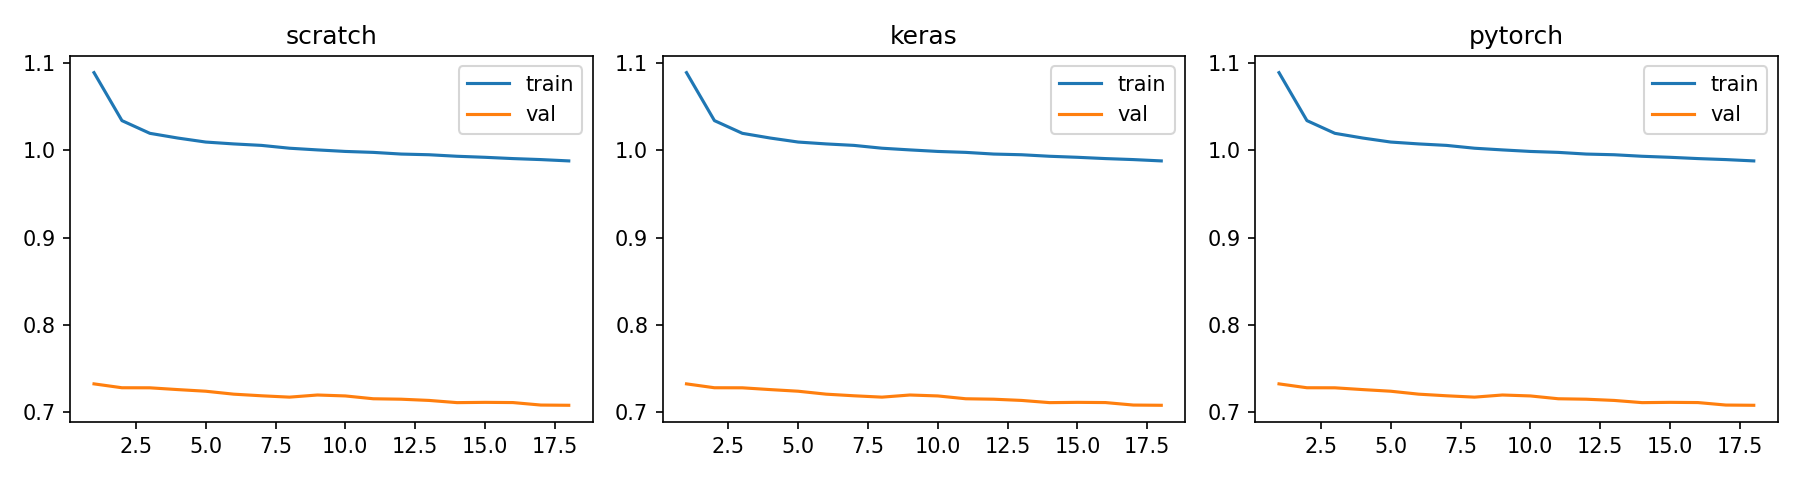

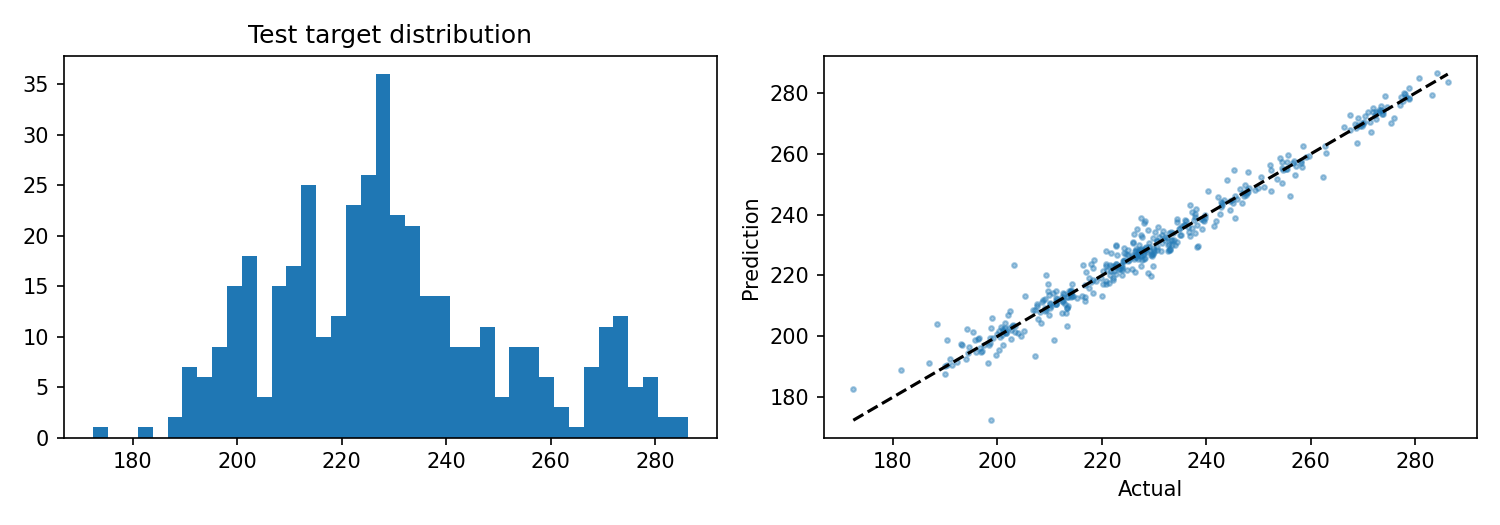

Baseline: {
  "RMSE": 3.904562960342821,
  "MAE": 2.641559260906556,
  "R2": 0.971054924808145
}
Chọn validation: {"framework": "scratch", "criterion": "RMSE", "split": "validation"}


,index,actual,prediction,absolute_error
0,2503,198.850006,172.609034,26.240972
1,2499,203.190002,223.561435,20.371433
2,2500,188.380005,203.919379,15.539375
3,2296,207.149994,193.569125,13.580868
4,2525,210.789993,198.900784,11.889210
5,2481,227.479996,239.019920,11.539924
6,2333,209.270004,220.286479,11.016475
7,2502,172.419998,182.729096,10.309098


In [11]:
display(summarize('stock').round(5))
for file in ['learning.png','evaluation.png','samples.png']:
    path=ROOT/'results/stock'/file
    if path.exists():display(Image(filename=str(path)))
print('Baseline:',(ROOT/'results/stock/baseline.json').read_text())
print('Chọn validation:',(ROOT/'results/stock/selection.json').read_text())
display(pd.read_json(ROOT/'results/stock/errors.json'))

## 4. Dataset customer
Online Retail II: gom 8 tuần × 6 tổng giao dịch → có đơn ở tuần kế tiếp. Chỉ khách có mua trong tám tuần trước, các mốc nhãn cách bốn tuần. CustomerID không làm predictor, nhưng khách có thể xuất hiện ở nhiều thời kỳ. Weighted softmax hai lớp, ngưỡng argmax (0,5), không gọi là churn.

In [12]:
import subprocess
if not (ROOT/'data/customer.npz').exists():
    subprocess.run([sys.executable,str(ROOT/'tools/prepare.py'),'customer'],check=True)
data=load('customer')
display(pd.Series(data['meta']))
print('Input shape:',data['x'].shape)
display(pd.DataFrame(data['x'][data['train'][:3]].reshape(3,-1)[:,:8]))
print('Nhãn mẫu:',data['raw_y'][data['train'][:3]])

kind                                                       rnn
task                                            classification
classes                                [No purchase, Purchase]
raw_rows                                               1067371
source       https://github.com/tuananhtrieu1305/ISD_Assign...
protocol     Chronological 70/15/15 by target week; returni...
transform    log1p nonnegative weekly aggregates, then trai...
features     [Orders, Quantity, Revenue, DistinctItems, Act...
mean         [0.13874545693397522, 0.9298350214958191, 1.05...
std          [0.30376744270324707, 2.0236244201660156, 2.26...
y_mean                                                     0.0
y_std                                                      1.0
periods      {'train': ['2010-01-25', '2011-04-18'], 'valid...
details      {'dataset': 'UCI Online Retail II', 'features'...
key                                                   customer
shape                                                  

Input shape: (39353, 8, 6)


,0,1,2,3,4,5,6,7
0,-0.456749,-0.459490,-0.466054,-0.445322,-0.467824,-0.466628,-0.456749,-0.459490
1,-0.456749,-0.459490,-0.466054,-0.445322,-0.467824,-0.466628,1.825086,2.375311
2,1.825086,2.498792,2.458763,2.561710,2.009549,2.516070,-0.456749,-0.459490


Nhãn mẫu: [0. 0. 0.]


### Tiền xử lý cụ thể
Mã chuẩn bị dữ liệu được trình bày dưới đây để đối chiếu fit scope và nguồn. Khi cần tái tạo cache, chạy tools/prepare.py với tên dataset. Chuỗi thời gian có thêm prepare_sequences.py.

In [13]:
display(Code(filename=str(ROOT/'tools/prepare.py'),language='python'))

from pathlib import Path
import json,sys,io,zipfile,hashlib
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split,GroupShuffleSplit
ROOT=Path(__file__).resolve().parents[1]
DATA=ROOT/'data'
def save(key,x,y,split,meta,extras=None):
    out=ROOT/'results'/key;out.mkdir(parents=True,exist_ok=True)
    meta.update(key=key,shape=list(x.shape[1:]),samples=len(y),splits={k:len(v) for k,v in split.items()})
    if meta['task']=='classification':meta['counts']={k:np.bincount(y[v].astype(int),minlength=len(meta['classes'])).tolist() for k,v in split.items()}
    np.savez_compressed(DATA/f'{key}.npz',x=x.astype(np.float32),y=y,**split,**(extras or {}))
    (out/'summary.json').write_text(json.dumps(meta,ensure_ascii=False,indent=2),encoding='utf-8')
    print(key,meta['splits'],flush=True)

def split_random(y):
    ix=np.arange(len(y));tr,te=train_test_split(ix,test_size=.2,random_state=42,stratify=y)
    tr,va=train_test_split(tr,test_size=.2,random_state=42,stratify=y[tr]);return dict(train=tr,val=va,test=te)

def tabular(key):
    if key=='diabetes':
        df=pd.read_csv(DATA/'diabetes.csv');raw_count=len(df);df=df.drop_duplicates()
        target=(df.pop('Diabetes_012').to_numpy()>0).astype(np.int64)
        features=list(df);raw=df.to_numpy(np.float32);groups=pd.util.hash_pandas_object(df,index=False).to_numpy()
        tr,te=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=42).split(raw,target,groups))
        a,b=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=42).split(raw[tr],target[tr],groups[tr]));split=dict(train=tr[a],val=tr[b],test=te)
        # Subset each split by labels after grouping; no identical predictor crosses splits.
        for k,n in [('train',16000),('val',4000),('test',5000)]:
            ix=split[k]
            if len(ix)>n:split[k]=train_test_split(ix,train_size=n,random_state=42,stratify=target[ix])[0]
        chosen=np.concatenate(list(split.values()));mapping={int(v):i for i,v in enumerate(chosen)}
        split={k:np.array([mapping[int(v)] for v in ix]) for k,ix in split.items()};raw=raw[chosen];y=target[chosen]
        meta=dict(kind='mlp',task='classification',classes=['No diabetes','Prediabetes or diabetes'],raw_rows=raw_count,features=features,source='https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset',protocol='Group by identical predictors; bounded stratified subsets within splits',transform='train mean/std')
    else:
        df=pd.read_csv(DATA/'house_prices.csv');raw_count=len(df);df=df.drop_duplicates()
        df=df[(df.Area>0)&(df.Price>0)].copy()
        features=['Area','Frontage','Access Road','Floors','Bedrooms','Bathrooms']
        raw=df[features].to_numpy(np.float32);raw[raw<0]=np.nan
        groups=df.Address.fillna('Unknown').astype(str).to_numpy()
        tr,te=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=42).split(df,groups=groups))
        a,b=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=42).split(df.iloc[tr],groups=groups[tr]));split=dict(train=tr[a],val=tr[b],test=te)
        median=np.nanmedian(raw[split['train']],axis=0);raw=np.where(np.isnan(raw),median,raw);y=df.Price.to_numpy(np.float32)
        meta=dict(kind='mlp',task='regression',raw_rows=raw_count,features=features,median=median.tolist(),source='https://www.kaggle.com/datasets/nguyentiennhan/vietnam-housing-dataset-2024',protocol='Group split by exact Address, 64/16/20 approximate rows; no location feature',transform='log1p numeric, train mean/std',unit='billion VND')
        raw=np.log1p(raw)
    mean=raw[split['train']].mean(0);std=raw[split['train']].std(0);std[std<1e-6]=1
    meta.update(mean=mean.tolist(),std=std.tolist())
    if key=='housing':
        z=np.log1p(y);ym=z[split['train']].mean();ys=z[split['train']].std();meta.update(y_mean=float(ym),y_std=float(ys));extras={'raw_y':y};y=(z-ym)/ys
    else:extras={'raw_y':y}
    save(key,(raw-mean)/std,y,split,meta,extras)



In [14]:
display(Code(filename=str(ROOT/'tools/prepare_sequences.py'),language='python'))

"""Freeze chronological train/validation/test samples; fit only on training data."""
from pathlib import Path
import sys,json
import numpy as np
import pandas as pd
ROOT=Path(__file__).resolve().parents[1]
sys.path.insert(0,str(ROOT/'src'))
from sequence_core import stock_features, STOCK_COLUMNS, STOCK_FEATURES, CUSTOMER_FEATURES

def save(key, x, y, times, metadata, extra):
    out=ROOT/'results'/key;out.mkdir(parents=True,exist_ok=True)
    unique=np.unique(times)
    a,b=int(len(unique)*.7),int(len(unique)*.85)
    train=np.flatnonzero(times<unique[a]);val=np.flatnonzero((times>=unique[a])&(times<unique[b]));test=np.flatnonzero(times>=unique[b])
    mean=x[train].mean(axis=(0,1),dtype=np.float64).astype(np.float32)
    std=x[train].std(axis=(0,1),dtype=np.float64).astype(np.float32);std[std<1e-8]=1
    xs=((x-mean)/std).astype(np.float32)
    ym=float(y[train].mean()) if key=='stock' else 0.
    ys=float(y[train].std()) if key=='stock' else 1.
    ys=max(ys,1e-8)
    metadata.update({'key':key,'samples':len(y),'input_shape':list(x.shape[1:]),'train':len(train),'validation':len(val),'test':len(test),
                     'x_mean':mean.tolist(),'x_std':std.tolist(),'y_mean':ym,'y_std':ys,
                     'periods':{k:[str(times[ix[0]]),str(times[ix[-1]])] for k,ix in [('train',train),('validation',val),('test',test)]}})
    if key=='customer':metadata['positive_rates']={k:float(y[ix].mean()) for k,ix in [('train',train),('validation',val),('test',test)]}
    np.savez_compressed(ROOT/'data'/f'{key}_prepared.npz',x=xs,y=((y-ym)/ys).astype(np.float32),raw_y=y,times=times.astype(str),train=train,val=val,test=test,**extra)
    np.savez_compressed(out/'split_indices.npz',train=train,val=val,test=test)
    (out/'data_summary.json').write_text(json.dumps(metadata,ensure_ascii=False,indent=2),encoding='utf-8')
    print(key,metadata['samples'],metadata['train'],metadata['validation'],metadata['test'],flush=True)

def stock():
    df=pd.read_csv(ROOT/'data/AAPL_2015_2025.csv',parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
    assert not df.Date.duplicated().any() and df[STOCK_COLUMNS].notna().all().all()
    raw=df[STOCK_COLUMNS].to_numpy(dtype=np.float64);features=stock_features(raw)
    targets=np.arange(79,len(df))
    x=np.stack([features[t-30:t] for t in targets]).astype(np.float32)
    y=np.log(raw[targets,3]/raw[targets-1,3]).astype(np.float32)
    assert np.isfinite(x).all()
    metadata={'dataset':'AAPL historical stock','raw_rows':len(df),'start':str(df.Date.iloc[0].date()),'end':str(df.Date.iloc[-1].date()),
              'features':STOCK_FEATURES,'lookback':30,'target':'Next-session log return; convert to Close = last Close * exp(return)',
              'split':'Chronological 70/15/15 by target date; features only from earlier dates','price_column':'Close (not Adj Close)'}
    save('stock',x,y,df.Date.dt.strftime('%Y-%m-%d').to_numpy()[targets],metadata,{'last_close':raw[targets-1,3],'actual_close':raw[targets,3],'raw_index':targets})

def customer():
    cache=ROOT/'data/retail_weekly.npz';audit_path=ROOT/'data/retail_audit.json'
    if cache.exists():
        z=np.load(cache,allow_pickle=False);dense=z['dense'];weeks=z['weeks'];ids=z['ids'];audit=json.loads(audit_path.read_text())
    else:
        sheets=pd.read_excel(ROOT/'data/online_retail_II.xlsx',sheet_name=None,engine='openpyxl')
        df=pd.concat(sheets.values(),ignore_index=True);df.columns=[str(c).strip() for c in df.columns]
        df=df.rename(columns={'Customer ID':'CustomerID','Invoice':'InvoiceNo','Price':'UnitPrice'})
        audit={'raw_rows':len(df),'sheets':list(sheets),'missing_customer_rows':int(df.CustomerID.isna().sum()),'duplicate_rows':int(df.duplicated().sum())}
        df=df.drop_duplicates().dropna(subset=['CustomerID','InvoiceDate'])
        keep=(df.Quantity>0)&(df.UnitPrice>0)&~df.InvoiceNo.astype(str).str.startswith('C')
        audit['nonpurchase_rows_excluded_after_dedup_and_id_filter']=int((~keep).sum())
      

### Huấn luyện scratch
Lưu history từng epoch, checkpoint tốt nhất, metric validation và dự đoán test. Không dùng trọng số hay số liệu từ bài mẫu.

In [15]:
row=train('customer','scratch')
display(row)

customer scratch 1 0.72006


customer scratch 2 0.71497


customer scratch 3 0.70962


customer scratch 4 0.70473


customer scratch 5 0.69343


...

customer scratch 15 0.64689


customer scratch 16 0.64979


customer scratch 17 0.64892


customer scratch 18 0.65313


{'framework': 'scratch',
 'seed': 42,
 'epochs': 18,
 'best_epoch': 15,
 'lr': 0.02,
 'batch': 128,
 'parameters': 402,
 'seconds': 3.037848599953577,
 'validation': {'Accuracy': 0.772757923128793,
  'MacroF1': 0.5877316231204579,
  'F1': 0.3115423901940756,
  'Precision': 0.2338957055214724,
  'Recall': 0.46636085626911317,
  'AP': 0.30063711007618166,
  'ROC_AUC': 0.7068203598573735},
 'test': {'Accuracy': 0.7585515766969535,
  'MacroF1': 0.6110264867566216,
  'F1': 0.3714782608695652,
  'Precision': 0.28525641025641024,
  'Recall': 0.5324027916251246,
  'AP': 0.31645248467445786,
  'ROC_AUC': 0.7017869397516446}}

### Huấn luyện keras
Lưu history từng epoch, checkpoint tốt nhất, metric validation và dự đoán test. Không dùng trọng số hay số liệu từ bài mẫu.

In [16]:
row=train('customer','keras')
display(row)

customer keras 1 0.72006


customer keras 2 0.71497


customer keras 3 0.70962


customer keras 4 0.70473


customer keras 5 0.69343


...

customer keras 15 0.64689


customer keras 16 0.64979


customer keras 17 0.64892


customer keras 18 0.65313


{'framework': 'keras',
 'seed': 42,
 'epochs': 18,
 'best_epoch': 15,
 'lr': 0.02,
 'batch': 128,
 'parameters': 402,
 'seconds': 6.766996300080791,
 'validation': {'Accuracy': 0.772757923128793,
  'MacroF1': 0.5877316231204579,
  'F1': 0.3115423901940756,
  'Precision': 0.2338957055214724,
  'Recall': 0.46636085626911317,
  'AP': 0.30063711007618166,
  'ROC_AUC': 0.7068205047088312},
 'test': {'Accuracy': 0.7585515766969535,
  'MacroF1': 0.6110264867566216,
  'F1': 0.3714782608695652,
  'Precision': 0.28525641025641024,
  'Recall': 0.5324027916251246,
  'AP': 0.3164525387673678,
  'ROC_AUC': 0.7017869397516446}}

### Huấn luyện pytorch
Lưu history từng epoch, checkpoint tốt nhất, metric validation và dự đoán test. Không dùng trọng số hay số liệu từ bài mẫu.

In [17]:
row=train('customer','pytorch')
display(row)

customer pytorch 1 0.72006


customer pytorch 2 0.71497


customer pytorch 3 0.70962


customer pytorch 4 0.70473


customer pytorch 5 0.69343


...

customer pytorch 15 0.64689


customer pytorch 16 0.64979


customer pytorch 17 0.64892


customer pytorch 18 0.65313


{'framework': 'pytorch',
 'seed': 42,
 'epochs': 18,
 'best_epoch': 15,
 'lr': 0.02,
 'batch': 128,
 'parameters': 402,
 'seconds': 9.144568099989556,
 'validation': {'Accuracy': 0.772757923128793,
  'MacroF1': 0.5877316231204579,
  'F1': 0.3115423901940756,
  'Precision': 0.2338957055214724,
  'Recall': 0.46636085626911317,
  'AP': 0.30063711007618166,
  'ROC_AUC': 0.7068203598573735},
 'test': {'Accuracy': 0.7585515766969535,
  'MacroF1': 0.6110264867566216,
  'F1': 0.3714782608695652,
  'Precision': 0.28525641025641024,
  'Recall': 0.5324027916251246,
  'AP': 0.3164525387673678,
  'ROC_AUC': 0.7017870166694794}}

### So sánh và phân tích
Đọc số liệu và hình do các lần train vừa tạo. Metric giữa các framework gần nhau là điều có thể xảy ra khi cùng khởi tạo và cùng SGD; không tự suy ra framework nào tốt hơn từ một seed.

,Framework,Accuracy,MacroF1,F1,Precision,Recall,AP,ROC_AUC,Parameters,TrainSeconds,BestEpoch
0,scratch,0.75855,0.61103,0.37148,0.28526,0.5324,0.31645,0.70179,402,3.03785,15
1,keras,0.75855,0.61103,0.37148,0.28526,0.5324,0.31645,0.70179,402,6.76700,15
2,pytorch,0.75855,0.61103,0.37148,0.28526,0.5324,0.31645,0.70179,402,9.14457,15


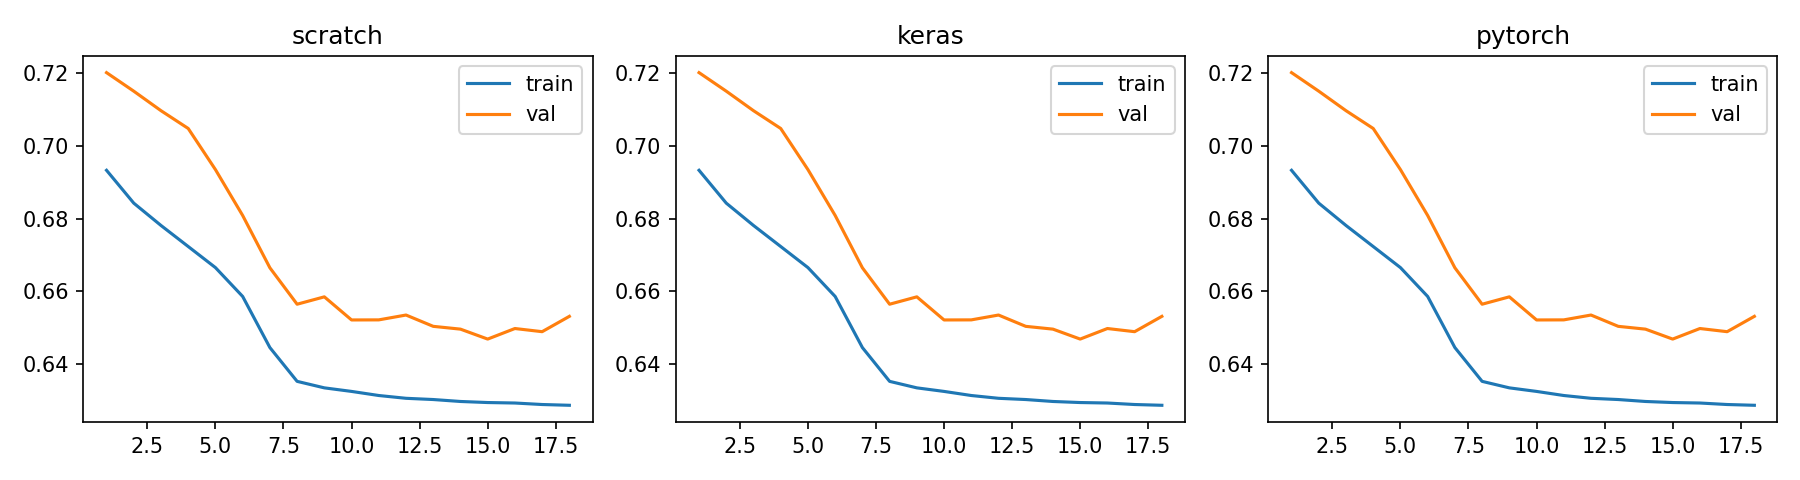

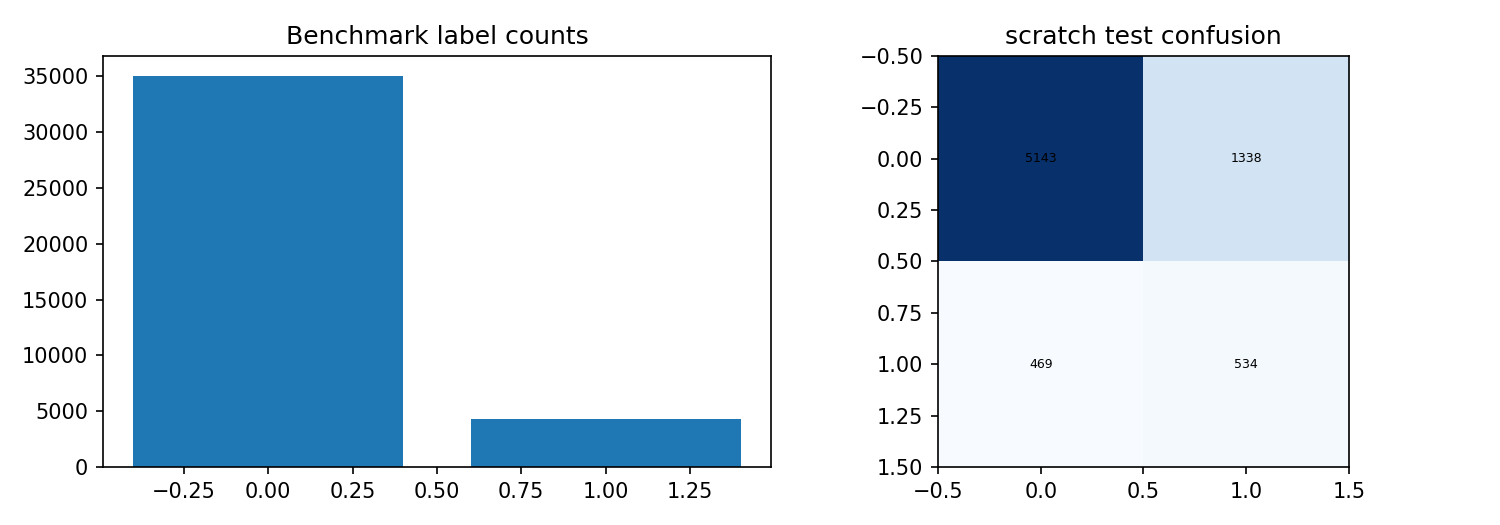

Baseline: {
  "Accuracy": 0.8659807589524319,
  "MacroF1": 0.4640887934121017
}
Chọn validation: {"framework": "scratch", "criterion": "MacroF1", "split": "validation"}


,index,actual,prediction,score
0,31887,0,1,0.820098
1,31888,0,1,0.560717
2,31893,0,1,0.737965
3,31898,1,0,0.540012
4,31906,0,1,0.627759
5,31911,0,1,0.586978
6,31912,1,0,0.638069
7,31915,1,0,0.548151


In [18]:
display(summarize('customer').round(5))
for file in ['learning.png','evaluation.png','samples.png']:
    path=ROOT/'results/customer'/file
    if path.exists():display(Image(filename=str(path)))
print('Baseline:',(ROOT/'results/customer/baseline.json').read_text())
print('Chọn validation:',(ROOT/'results/customer/selection.json').read_text())
display(pd.read_json(ROOT/'results/customer/errors.json'))

## 5. Tiểu kết
Mỗi dataset có ba implementation được train độc lập. Kết quả chỉ áp dụng cho cấu hình nhỏ và seed42, chưa có đánh giá nhiều seed. Báo cáo nêu baseline và failure cases; không chọn model bằng test. Kiểm tra gradient bằng tools/check_gradients.py và checkpoint bằng tools/verify.py.

## Bổ sung so sánh mô hình khác nhau
Xem [notebook 06](06_architecture_comparison.ipynb): ba họ mô hình ML và bốn kiến trúc CNN/RNN trên các dataset hiện tại. Phần ở notebook này đối chiếu ba cách cài đặt của kiến trúc cơ sở; không coi ba thư viện là ba thuật toán khác nhau.